https://energy-charts.info/charts/installed_power/chart.htm?l=de&c=DE&year=2024

PV: 92.4 GW
Wind Onshore: 63.6 GW
Erdgas: 35.6 GW
Braunkohle: 15.1 GW
Steinkohle: 15.6 GW

https://www.umweltbundesamt.de/system/files/medien/11850/publikationen/2026-03/16_2026_CC.pdf

Erdgas: 202 g/kWh 51%
Steinkohle: 338 g/kWh 39%
Braunkohle: 407 g/kWh 36%


https://github.com/PyPSA/technology-data/blob/master/inputs/Fraunhofer_ISE_energy_prices.csv

Erdgas: 23 €/MWh
Steinkohle: 13 €/MWh
Braunkohle: 2 €/MWh



Importieren Sie die Pandas und PyPSA Bibiliothek.

In [1]:
import pypsa
import pandas as pd


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Felix\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Felix\AppData\Local\Programs\Python\Python311\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Felix\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelapp.py", 

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Felix\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Felix\AppData\Local\Programs\Python\Python311\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Felix\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\kernelapp.py", 

AttributeError: _ARRAY_API not found

In [2]:
df_data = pd.read_csv('data_PyPSA_3.csv', index_col='Datum')

print(df_data)

                  Netzlast [MW]  Windpotential [MW]  Solarpotential [MW]
Datum                                                                   
2024-04-09 00:00        43559.3             13318.6                  0.0
2024-04-09 01:00        42094.8             13861.9                  0.0
2024-04-09 02:00        41395.0             14064.5                  0.0
2024-04-09 03:00        42502.3             13227.3                  0.0
2024-04-09 04:00        43580.5             13109.1                  0.0
2024-04-09 05:00        47219.3             14446.2                  0.0
2024-04-09 06:00        55208.5             16091.7                121.3
2024-04-09 07:00        59665.8             17332.3               2388.7
2024-04-09 08:00        62712.5             16673.8               7001.4
2024-04-09 09:00        63376.5             15585.6              12327.8
2024-04-09 10:00        63805.8             15762.0              16956.0
2024-04-09 11:00        64142.3             18272.2

In [3]:
cap_pv = 92400 # MW
cap_wind = 63400 # MW
cap_coal = 15100 # MW
cap_lignite = 15600 # MW
cap_gas = 35600 # MW

co2_coal = 0.407 # t/MWh
co2_lignite = 0.338 # t/MWh
co2_gas = 0.202 # t/MWh

eff_coal = 0.51     #MWh_el / MWh_th
eff_lignite = 0.39
eff_gas = 0.36

cost_coal = 2 # €/MWh
cost_lignite = 13 # €/MWh
cost_gas = 23 # €/MWh

C:\Users\Felix\AppData\Local\Temp\ipykernel_16980\177832672.py:29: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['DE_LU'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.11s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 120 primals, 264 duals
Objective: 5.51e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


                      Optimal Capacity  Installed Capacity    Supply  \
Generator Braunkohle           15100.0             15100.0  362400.0   
          Gas                  35600.0             35600.0   41075.6   
          PV                   92400.0             92400.0  145797.0   
          Steinkohle           15600.0             15600.0  295533.8   
          Wind                 63400.0             63400.0  508540.7   
Load      -                        0.0                 0.0       0.0   

                      Withdrawal  Energy Balance Transmission  \
Generator Braunkohle         0.0        362400.0          0.0   
          Gas                0.0         41075.6          0.0   
          PV                 0.0        145797.0          0.0   
          Steinkohle         0.0        295533.8          0.0   
          Wind               0.0        508540.7          0.0   
Load      -            1353347.1      -1353347.1          0.0   

                      Capacity Factor  

<Axes: xlabel='snapshot'>

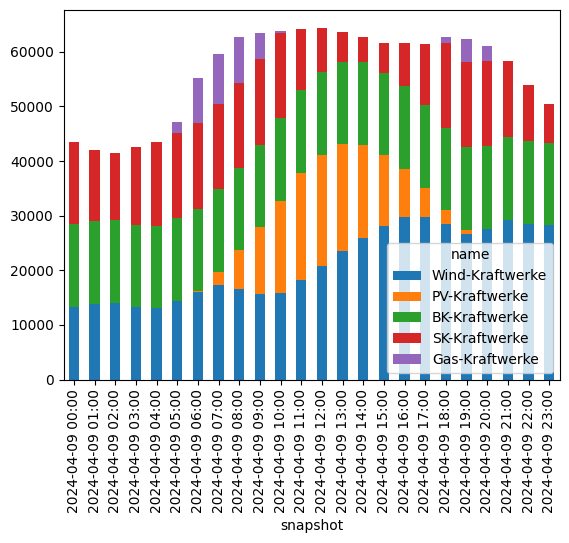

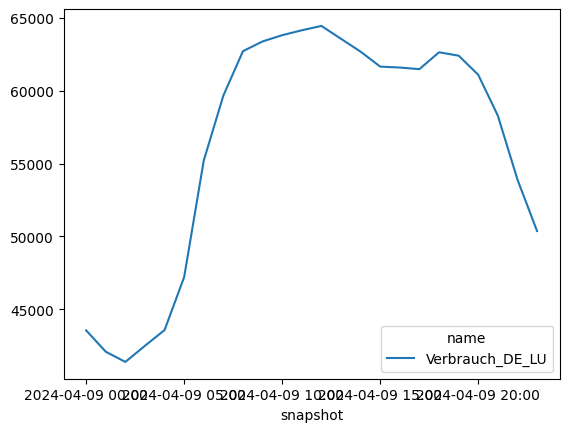

In [4]:
# PyPSA Netzwerk
network = pypsa.Network()

network.set_snapshots(df_data.index)
# pd.date_range('2024-04-09', periods=24, freq='h')
# Carrier
network.add('Carrier', name = 'PV', co2_emissions=0)
network.add('Carrier', name = 'Wind', co2_emissions=0)
network.add('Carrier', name = 'Braunkohle', co2_emissions=co2_coal)
network.add('Carrier', name = 'Steinkohle', co2_emissions=co2_lignite)
network.add('Carrier', name = 'Gas', co2_emissions=co2_gas)

# Bus
network.add('Bus', name = 'DE_LU')

# Load
network.add('Load', name = 'Verbrauch_DE_LU', bus = 'DE_LU', p_set=df_data["Netzlast [MW]"])

# Generator
network.add('Generator', name = 'Wind-Kraftwerke', bus = 'DE_LU', carrier='Wind', p_nom=cap_wind, p_max_pu=df_data["Windpotential [MW]"]/cap_wind, marginal_cost=0)
network.add('Generator', name = 'PV-Kraftwerke', bus = 'DE_LU', carrier='PV', p_nom=cap_pv, p_max_pu=df_data["Solarpotential [MW]"]/cap_pv, marginal_cost=0)
network.add('Generator', name = 'BK-Kraftwerke', bus = 'DE_LU', carrier='Braunkohle', p_nom=cap_coal, efficiency=eff_coal, marginal_cost=cost_coal)
network.add('Generator', name = 'SK-Kraftwerke', bus = 'DE_LU', carrier='Steinkohle', p_nom=cap_lignite, efficiency=eff_lignite, marginal_cost=cost_lignite)
network.add('Generator', name = 'Gas-Kraftwerke', bus = 'DE_LU', carrier='Gas', p_nom=cap_gas, efficiency=eff_gas, marginal_cost=cost_gas)


#network.add('GlobalConstraint', name = 'co2-limt', carrier_attribute = 'co2_emissions', sense = '<=', overwrite=True, constant = 250000)

network.optimize()
print(network.statistics())
network.generators_t.p.plot.bar(stacked=True)
network.loads_t.p.plot()

